Non Demented: 67222 images
Very mild Dementia: 13725 images
Moderate Dementia: 488 images
Mild Dementia: 5002 images


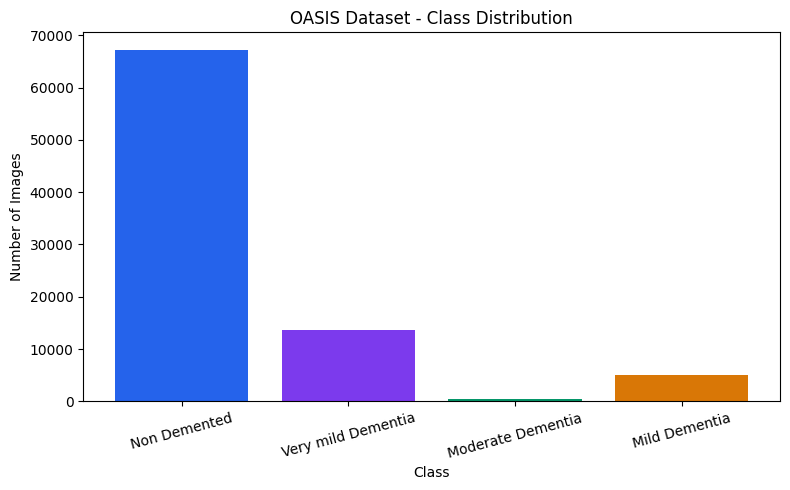

In [6]:
import os
import matplotlib.pyplot as plt

# Correct path
dataset_path = "/kaggle/input/datasets/ninadaithal/imagesoasis/Data"

# Count images per class
classes = os.listdir(dataset_path)
class_counts = {}

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    class_counts[cls] = count
    print(f"{cls}: {count} images")

# Plot distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(),
        color=['#2563eb', '#7c3aed', '#059669', '#d97706'])
plt.title('OASIS Dataset - Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

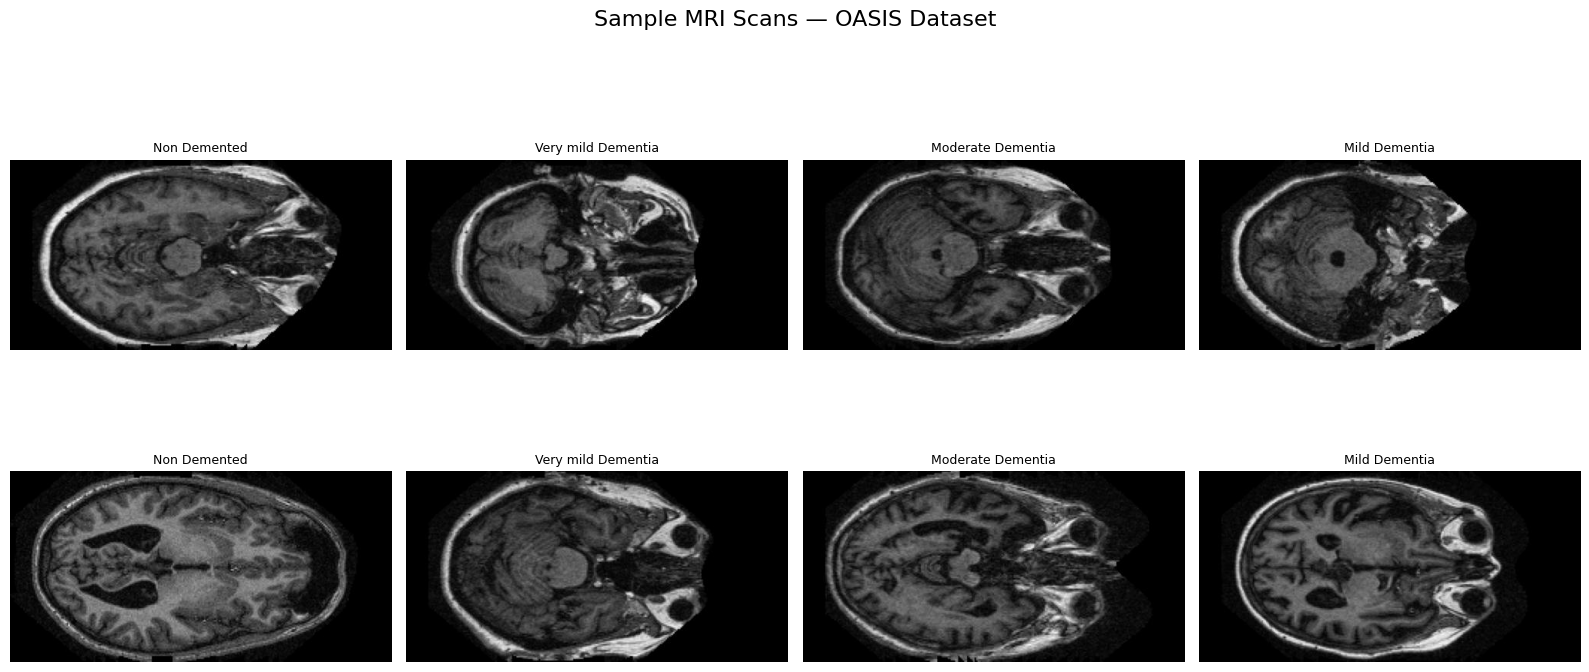

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample MRI Scans — OASIS Dataset', fontsize=16)

for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    
    for row in range(2):
        img_path = os.path.join(cls_path, random.choice(images))
        img = mpimg.imread(img_path)
        axes[row][idx].imshow(img, cmap='gray')
        axes[row][idx].set_title(cls, fontsize=9)
        axes[row][idx].axis('off')

plt.tight_layout()
plt.show()

In [8]:
from PIL import Image
import numpy as np

# Check image sizes and properties
sample_class = classes[0]
sample_path = os.path.join(dataset_path, sample_class)
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))

print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")
print(f"Image format: {sample_img.format}")

# Check if all images are same size
sizes = set()
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path)[:50]:  # check first 50
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.add(img.size)

print(f"\nUnique image sizes found: {sizes}")

Image size: (496, 248)
Image mode: RGB
Image format: JPEG

Unique image sizes found: {(496, 248)}


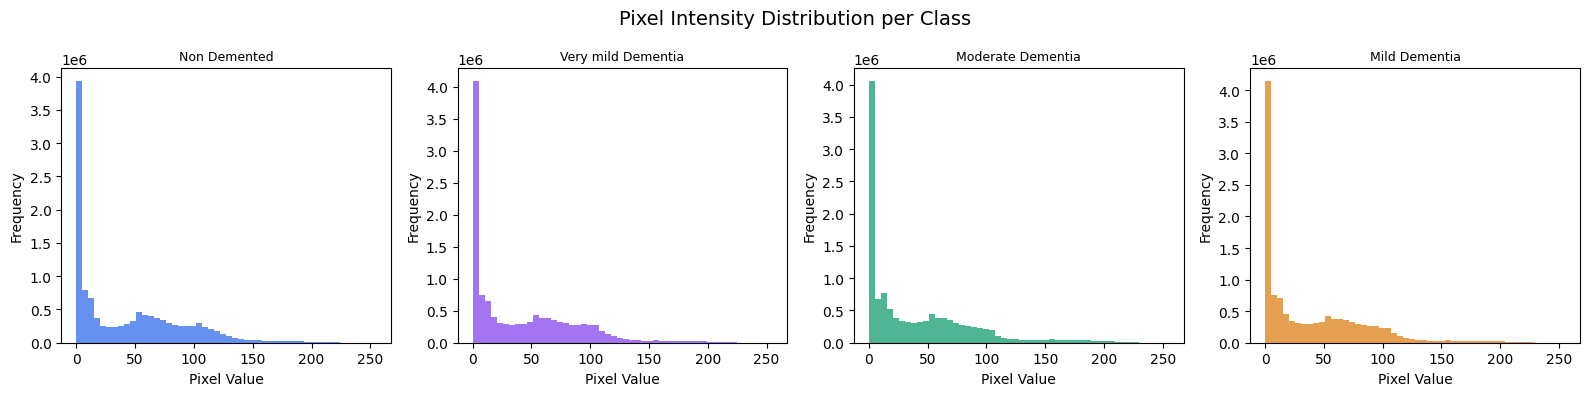

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Pixel Intensity Distribution per Class', fontsize=14)

for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    
    # Sample 100 images
    sample_imgs = random.sample(images, min(100, len(images)))
    pixels = []
    
    for img_name in sample_imgs:
        img = np.array(Image.open(os.path.join(cls_path, img_name)).convert('L'))
        pixels.extend(img.flatten().tolist())
    
    axes[idx].hist(pixels, bins=50, color=['#2563eb', '#7c3aed', '#059669', '#d97706'][idx], alpha=0.7)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
total = sum(class_counts.values())

print("=" * 45)
print(f"{'CLASS':<25} {'COUNT':>8} {'PERCENT':>8}")
print("=" * 45)
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:<25} {count:>8} {count/total*100:>7.1f}%")
print("=" * 45)
print(f"{'TOTAL':<25} {total:>8} {'100.0%':>8}")

print("\n⚠️  Severe imbalance detected.")
print(f"Majority class is {max(class_counts, key=class_counts.get)}")
print(f"Minority class is {min(class_counts, key=class_counts.get)}")
ratio = max(class_counts.values()) / min(class_counts.values())
print(f"Imbalance ratio: {ratio:.1f}x")
print("\nStrategy: Use weighted loss + augmentation on minority classes")

CLASS                        COUNT  PERCENT
Non Demented                 67222    77.8%
Very mild Dementia           13725    15.9%
Mild Dementia                 5002     5.8%
Moderate Dementia              488     0.6%
TOTAL                        86437   100.0%

⚠️  Severe imbalance detected.
Majority class is Non Demented
Minority class is Moderate Dementia
Imbalance ratio: 137.8x

Strategy: Use weighted loss + augmentation on minority classes


# 01 — Data Exploration
## OASIS Alzheimer's Detection Dataset

### Dataset Overview
The OASIS dataset contains **86,437 MRI brain scans** across 4 dementia 
severity classes, sourced from the Open Access Series of Imaging Studies.

### Class Distribution
| Class | Count | Percentage |
|-------|-------|------------|
| Non Demented | 67,222 | 77.8% |
| Very Mild Dementia | 13,725 | 15.9% |
| Mild Dementia | 5,002 | 5.8% |
| Moderate Dementia | 488 | 0.6% |

### Image Properties
- **Size:** 496 × 248 pixels (non-square)
- **Format:** JPEG
- **Mode:** RGB (3 channels)
- **Pixel range:** 0–255, heavily skewed toward dark values (black background)

### Key Findings
1. **Severe class imbalance** — imbalance ratio of 137.8x between majority 
   and minority class. Standard accuracy is not a reliable metric here.
2. **Consistent image dimensions** — all images are identical size, 
   simplifying preprocessing.
3. **Non-square format** — requires resizing to 224×224 for ViT input.
4. **Dark pixel distribution** — normalization is essential before training.

### Preprocessing Decisions (for next notebook)
- Resize to 224×224
- Normalize pixel values to [0, 1]
- Apply augmentation on minority classes
- Use weighted cross-entropy loss during training
- Evaluate using F1 score and confusion matrix, not accuracy alone